# CNN with MNIST — PyTorch

> **Maqsad:** Qo‘lda yozilgan raqamlarning rasmini CNN yordamida 0–9 orasida klassifikatsiya qilish.
>
> **Dataset:** MNIST (28×28 grayscale rasmlar).
>
> **Model oqimi:** Image → Convolution → ReLU → MaxPooling → Convolution → ReLU → MaxPooling → Flatten → Linear → 10 class logits.



## 1. Kutubxonalarni import qilish

Bu bo‘limda PyTorch, MNIST datasetini yuklash va rasmlarni ko‘rsatish uchun kerakli kutubxonalarni chaqiramiz.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Natijalarni qayta olish osonroq bo‘lishi uchun seed
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("PyTorch:", torch.__version__)

Device: cpu
PyTorch: 2.14.0


## 2. MNIST datasetini yuklash

Har bir rasmning o‘lchami 28×28. `ToTensor()` piksel qiymatlarini tensor ko‘rinishiga o‘tkazadi va odatda [0, 1] oralig‘iga keltiradi.

In [2]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Train rasmlar:", len(train_dataset))
print("Test rasmlar:", len(test_dataset))
print("Bitta rasm shape:", train_dataset[0][0].shape)  # [1, 28, 28]
print("Birinchi rasm labeli:", train_dataset[0][1])

100.0%
100.0%
100.0%
100.0%

Train rasmlar: 60000
Test rasmlar: 10000
Bitta rasm shape: torch.Size([1, 28, 28])
Birinchi rasm labeli: 5


## 3. Bir nechta rasmni ko‘rish

MNIST labeli 0–9 oralig‘idagi raqamni bildiradi. Masalan, label `7` bo‘lsa, rasmda qo‘lda yozilgan 7 raqami bor.

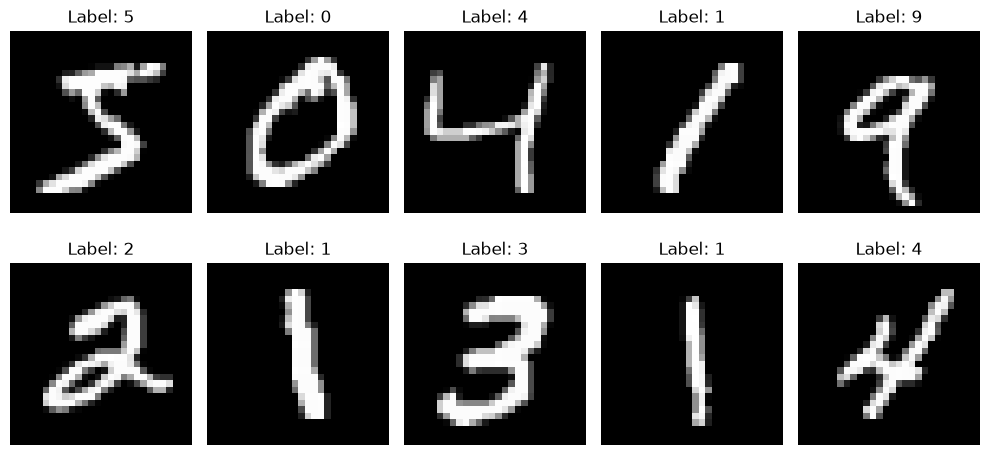

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4. DataLoader va batch_size

**Batch size = 64**: model bir qadamda 64 ta rasmni oladi va 64 ta prediction chiqaradi. Har bir rasmning o‘z labeli bor.

In [4]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

images, labels = next(iter(train_loader))
print("Images shape:", images.shape)  # [64, 1, 28, 28]
print("Labels shape:", labels.shape)  # [64]
print("Birinchi 10 label:", labels[:10].tolist())

Images shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])
Birinchi 10 label: [1, 2, 8, 5, 2, 6, 9, 9, 9, 4]


## 5. CNN modelini yaratish

- `Conv2d`: rasmdagi patternlarni (masalan, chiziq va qirralarni) o‘rganadi.
- `ReLU`: manfiy qiymatlarni 0 qiladi.
- `MaxPool2d`: feature map o‘lchamini kichraytiradi.
- `Flatten`: 2D feature maplarni bitta vektorga aylantiradi.
- `Linear`: yakuniy 10 ta class uchun logits chiqaradi.

MNIST grayscale bo‘lgani uchun input channel = 1. Oxirgi layer 10 ta raqam (0–9) uchun 10 ta logit chiqaradi.

In [5]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),  # 28x28 -> 14x14

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)   # 14x14 -> 7x7
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)  # 10 ta class uchun logits
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = MNIST_CNN().to(device)
print(model)

# Shape larni tekshirish
sample_images, sample_labels = next(iter(train_loader))
sample_images = sample_images.to(device)
with torch.no_grad():
    sample_outputs = model(sample_images)

print("Input shape:", sample_images.shape)
print("Output shape:", sample_outputs.shape)  # [64, 10]

MNIST_CNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)
Input shape: torch.Size([64, 1, 28, 28])
Output shape: torch.Size([64, 10])


## 6. Loss function va Optimizer

`CrossEntropyLoss` logits va true labels asosida xatolikni hisoblaydi. Shuning uchun modeldan keyin alohida Softmax qo‘shmaymiz.

`Adam` — model weights qiymatlarini yangilash uchun optimizer. `learning_rate` yangilash qadamining kattaligini boshqaradi.

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 5

## 7. Modelni train qilish

Har bir batch uchun jarayon:
`Forward pass → Loss → Backpropagation → Weight update`.

Bir **epoch** — train datasetidagi barcha rasmlarni bir marta ko‘rish.

In [7]:
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)          # [batch_size, 10] logits
        loss = criterion(outputs, labels)

        loss.backward()                  # gradient hisoblash
        optimizer.step()                 # weights yangilash

        running_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] | "
        f"Loss: {epoch_loss:.4f} | "
        f"Train Accuracy: {epoch_acc:.4f}"
    )

Epoch [1/5] | Loss: 0.2210 | Train Accuracy: 0.9345
Epoch [2/5] | Loss: 0.0612 | Train Accuracy: 0.9814
Epoch [3/5] | Loss: 0.0423 | Train Accuracy: 0.9868
Epoch [4/5] | Loss: 0.0315 | Train Accuracy: 0.9901
Epoch [5/5] | Loss: 0.0255 | Train Accuracy: 0.9919


## 8. Test datasetda baholash

Bu bo‘limda model ilgari train qilinmagan test rasmlarida tekshiriladi. `torch.no_grad()` gradient hisoblashni o‘chiradi, `model.eval()` esa evaluation rejimini yoqadi.

In [8]:
model.eval()
correct = 0
total = 0
test_loss = 0.0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

print(f"Test Loss: {test_loss / total:.4f}")
print(f"Test Accuracy: {correct / total:.4%}")

Test Loss: 0.0324
Test Accuracy: 98.8400%


## 9. Model predictionlarini ko‘rish

Quyida test rasmlari, model predictioni va haqiqiy label ko‘rsatiladi. `argmax` eng katta logitga ega class indexini tanlaydi.

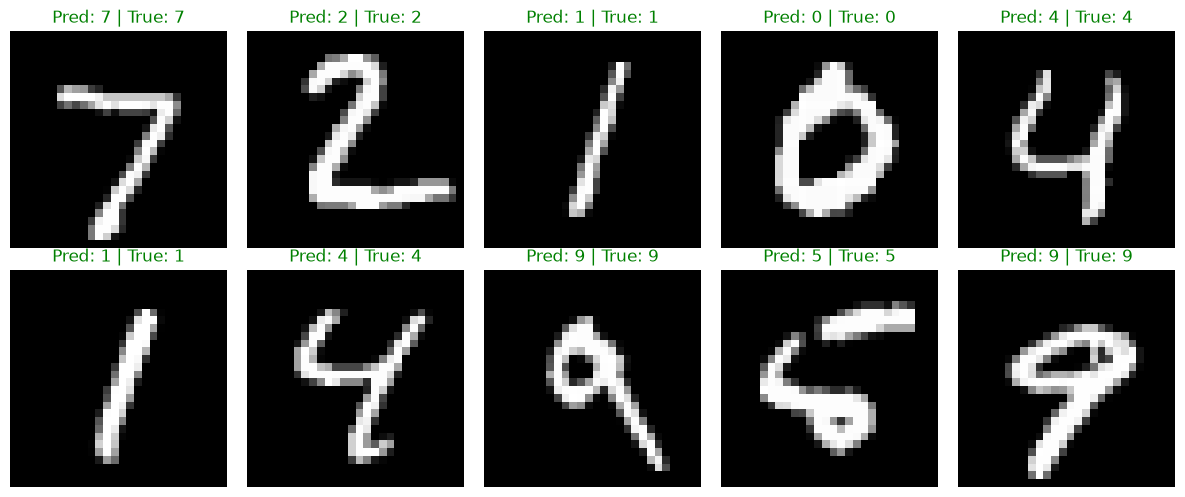

In [9]:
model.eval()
images, labels = next(iter(test_loader))

with torch.no_grad():
    outputs = model(images.to(device))
    predictions = outputs.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap="gray")
    pred = predictions[i].item()
    true = labels[i].item()
    ax.set_title(f"Pred: {pred} | True: {true}", 
                 color="green" if pred == true else "red")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 10. Modelni saqlash

Train qilingan model weightslarini faylga saqlaymiz. Keyinchalik model arxitekturasini qayta yaratib, ushbu weightslarni yuklash mumkin.

In [10]:
torch.save(model.state_dict(), "mnist_cnn.pth")
print("Model saqlandi: mnist_cnn.pth")

Model saqlandi: mnist_cnn.pth


## ✅ Qisqa xulosa

- MNIST: 28×28 grayscale rasmlar, 10 ta class (0–9).
- Har bir rasm uchun label bor.
- Batch size = 64 → odatda model bir qadamda 64 ta rasm uchun 64 ta prediction chiqaradi.
- Output shape: `[batch_size, 10]` — har bir rasm uchun 10 ta logits.
- `CrossEntropyLoss` logits va true labelsdan loss hisoblaydi; training vaqtida alohida Softmax shart emas.
- `argmax(dim=1)` predicted raqamni tanlaydi.
